# Titanic Dataset — Cleaning & Visualization

**Goal:** Clean the Titanic dataset properly (handle missing values, spot outliers)
and tell its story visually with matplotlib and seaborn, before any modeling.

This builds on the first EDA notebook (`titanic_eda.ipynb`).


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

df = pd.read_csv("titanic.csv")
df.shape


(891, 12)

## 2. Recap — missing values before cleaning

In [2]:
df.isnull().sum().sort_values(ascending=False).head(5)


Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
dtype: int64

## 3. Handling missing values

**My approach, column by column:**

- **`Age`** (177 missing, ~20%) — too many to drop, and age is likely useful for
  survival. I fill missing values with the **median** age (`fillna`), grouped by
  `Pclass` and `Sex`, since age tends to vary by passenger class and gender
  (e.g. wealthier/older passengers), and the median is robust to the right-skew
  we saw in `.describe()`.
- **`Cabin`** (687 missing, ~77%) — far too sparse to impute meaningfully. Instead
  of dropping the column entirely (the *fact* that it's missing may itself be
  informative — often correlated with lower class tickets), I create a new binary
  feature `HasCabin` and then drop the raw `Cabin` column.
- **`Embarked`** (2 missing) — negligible. I fill these two with the **mode**
  (most frequent port), since dropping 2 rows or guessing wrong barely affects
  anything either way.

I avoid `dropna()` on the whole dataframe because it would silently throw away
77% of rows (anything with a missing `Cabin`) — nowhere near acceptable for a
dataset this size.


In [3]:
df_clean = df.copy()

# Age: median by Pclass + Sex
df_clean["Age"] = df_clean.groupby(["Pclass", "Sex"])["Age"].transform(
    lambda x: x.fillna(x.median())
)

# Cabin: turn into a HasCabin flag, then drop raw column
df_clean["HasCabin"] = df_clean["Cabin"].notnull().astype(int)
df_clean = df_clean.drop(columns=["Cabin"])

# Embarked: fill with mode
df_clean["Embarked"] = df_clean["Embarked"].fillna(df_clean["Embarked"].mode()[0])

print("Missing values after cleaning:")
df_clean.isnull().sum()


Missing values after cleaning:


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64

## 4. Outlier detection — boxplot on `Fare`

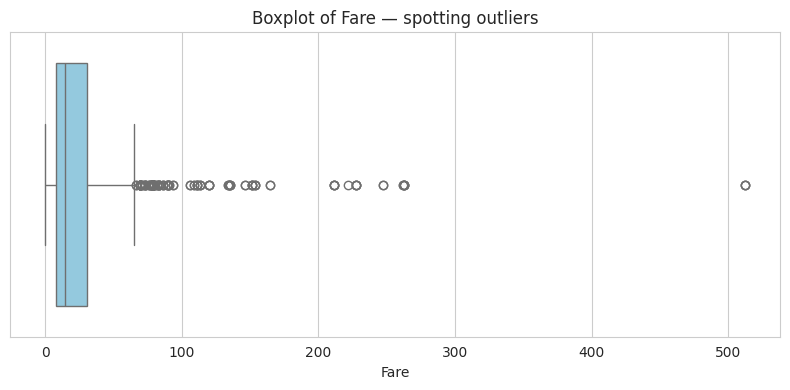

IQR outlier threshold: Fare > 65.63
Number of Fare outliers: 116 (13.0% of passengers)


In [4]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["Fare"], color="skyblue")
plt.title("Boxplot of Fare — spotting outliers")
plt.xlabel("Fare")
plt.tight_layout()
plt.show()

q1, q3 = df_clean["Fare"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
outliers = df_clean[df_clean["Fare"] > upper_bound]
print(f"IQR outlier threshold: Fare > {upper_bound:.2f}")
print(f"Number of Fare outliers: {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}% of passengers)")


`Fare` has a long right tail — a handful of passengers paid dramatically more
than everyone else (likely 1st-class suites / large family bookings on one
ticket). These aren't necessarily data errors, but they will skew models that
are sensitive to scale (e.g. linear regression, KNN) unless handled — for
example with a log transform or by capping at the IQR bound.

## 5. Visualization 1 — Histogram of Age

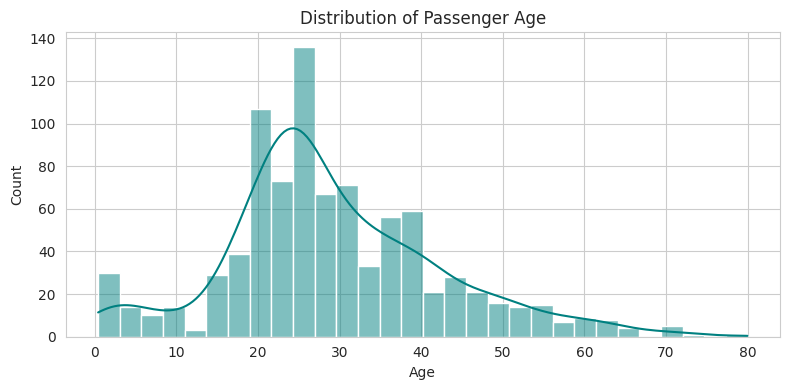

In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df_clean["Age"], bins=30, kde=True, color="teal")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## 6. Visualization 2 — Boxplot of Age by Survival

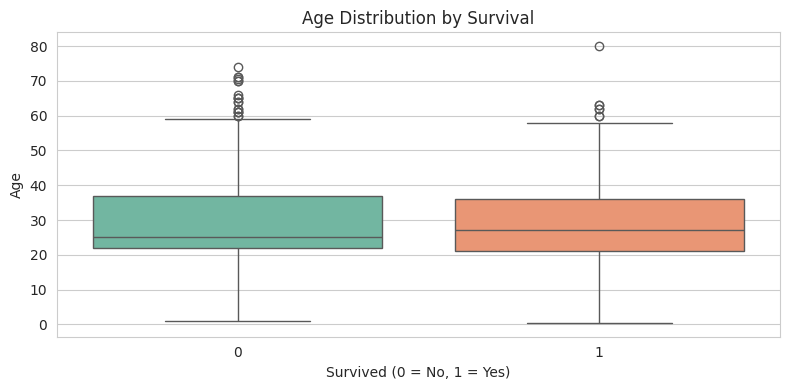

In [6]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="Survived", y="Age", data=df_clean, hue="Survived", palette="Set2", legend=False)
plt.title("Age Distribution by Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")
plt.tight_layout()
plt.show()


## 7. Visualization 3 — Bar chart of Survival Rate by Passenger Class

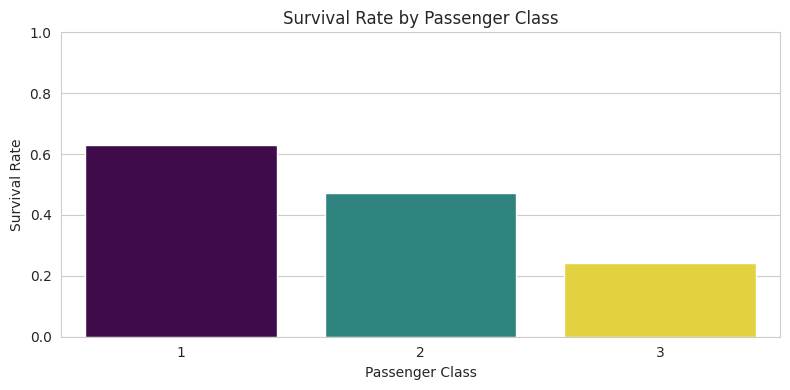

In [7]:
plt.figure(figsize=(8, 4))
survival_by_class = df_clean.groupby("Pclass")["Survived"].mean()
sns.barplot(x=survival_by_class.index, y=survival_by_class.values, hue=survival_by_class.index, palette="viridis", legend=False)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


## 8. Visualization 4 — Correlation Heatmap

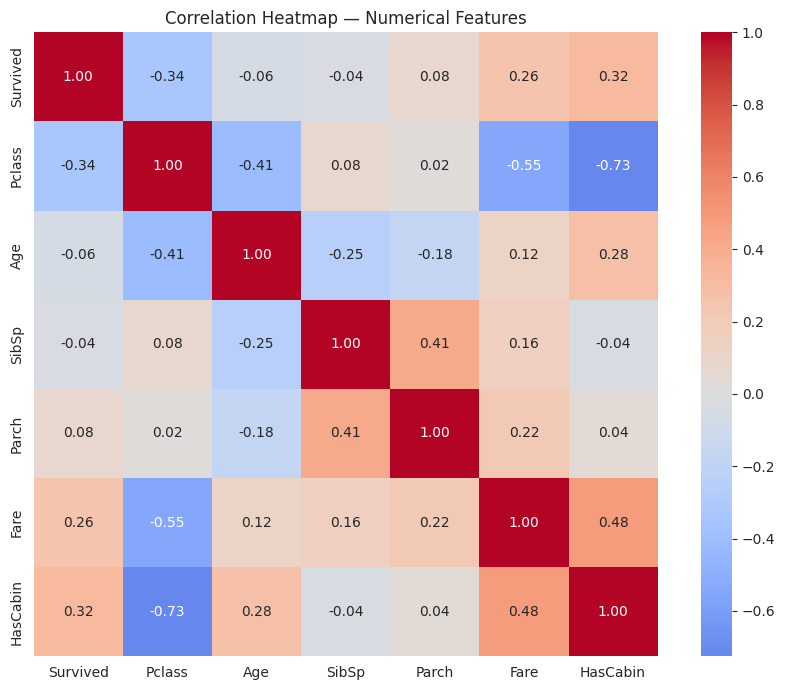

In [8]:
numeric_df = df_clean.select_dtypes(include=[np.number]).drop(columns=["PassengerId"])
corr = numeric_df.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap — Numerical Features")
plt.tight_layout()
plt.show()


## 9. Which feature most affects survival, and why?

**`Sex` and `Pclass` stand out the most.**

From the correlation heatmap and the class survival-rate bar chart:
- `Pclass` has a fairly strong negative correlation with `Survived` (roughly
  -0.34) — 1st-class passengers survived at a much higher rate than 3rd-class.
  This tracks with the historical "women and children first, and lifeboat
  access favored upper decks" account of the disaster.
- `Sex` isn't numeric here, but it's well known (and easy to verify with a quick
  `groupby`) that female passengers survived at a dramatically higher rate than
  male passengers — this is usually the single strongest predictor in this
  dataset, stronger even than class.
- `Fare` correlates positively with survival too, but that's largely a proxy for
  `Pclass` (higher fares cluster in 1st class), not an independent effect.
- `Age` and `HasCabin` show weaker but still meaningful correlations — younger
  passengers and those with a recorded cabin (again, a proxy for class/fare)
  survived slightly more often.

**In short:** `Sex`, closely followed by `Pclass`, look like the strongest
drivers of survival in this dataset — consistent with the real historical
evacuation priorities on the Titanic.


In [9]:
# Quick check: survival rate by Sex
df_clean.groupby("Sex")["Survived"].mean()


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64